<a href="https://colab.research.google.com/github/varshithgoud2407/AI-crime-type-prediction/blob/main/new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [ ]:
# LOAD DATASET
df = pd.read_csv("/content/Fraud_Data.csv")

print(df.head())
print(df.shape)

   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
3   150084  2015-04-28 21:13:25  2015-05-04 13:54:50              44   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   

       device_id source browser sex  age    ip_address  class  
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  7.327584e+08      0  
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  3.503114e+08      0  
2  YSSKYOSJHPPLJ    SEO   Opera   M   53  2.621474e+09      1  
3  ATGTXKYKUDUQN    SEO  Safari   M   41  3.840542e+09      0  
4  NAUITBZFJKHWW    Ads  Safari   M   45  4.155831e+08      0  
(151112, 11)


In [ ]:
# DATASET INFORMATION
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB
None
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dty

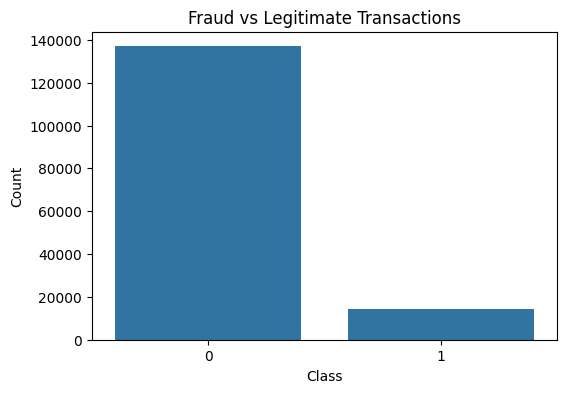

In [ ]:
# CLASS DISTRIBUTION
plt.figure(figsize=(6,4))

sns.countplot(x='class', data=df)

plt.title("Fraud vs Legitimate Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [ ]:
# CONVERT DATE COLUMNS
df['signup_time'] = pd.to_datetime(df['signup_time'])

df['purchase_time'] = pd.to_datetime(df['purchase_time'])

In [ ]:
# FEATURE ENGINEERING
df['time_difference_hours'] = (
    df['purchase_time'] - df['signup_time']
).dt.total_seconds() / 3600

# purchase hour

df['purchase_hour'] = df['purchase_time'].dt.hour

# purchase day

df['purchase_day'] = df['purchase_time'].dt.day

# purchase month

df['purchase_month'] = df['purchase_time'].dt.month

In [ ]:
# DROP UNNECESSARY COLUMNS
df.drop(
    columns=[
        'user_id',
        'device_id',
        'signup_time',
        'purchase_time',
        'ip_address'
    ],
    inplace=True
)

In [ ]:
# ENCODE CATEGORICAL VARIABLES
encoder = LabelEncoder()

categorical_cols = [
    'source',
    'browser',
    'sex'
]

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

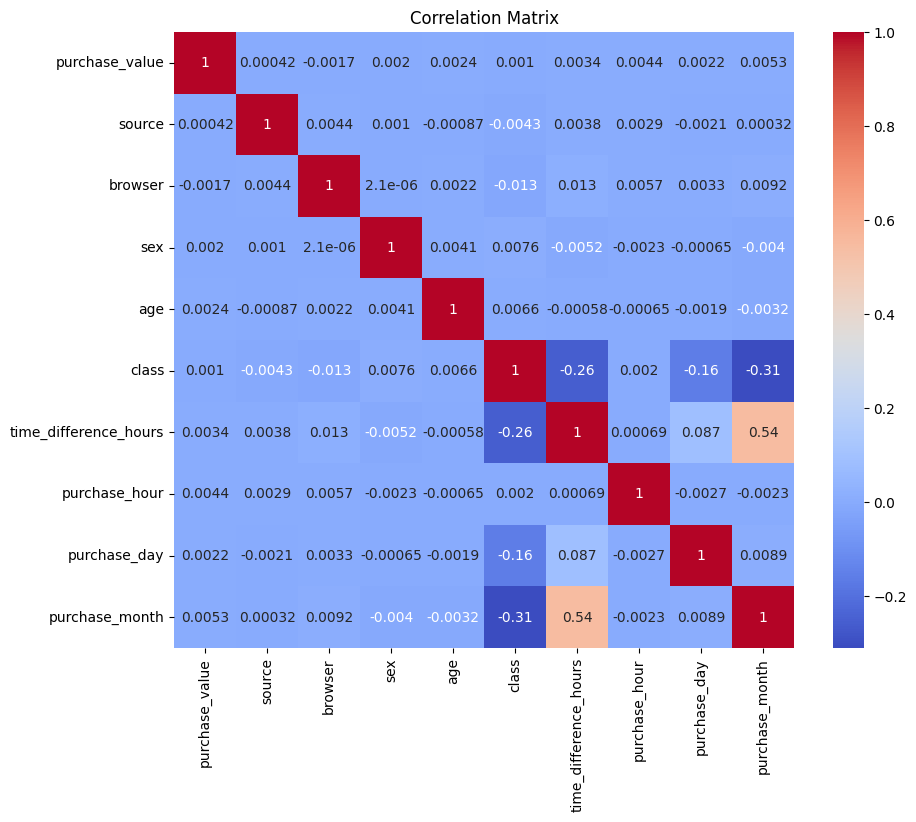

In [ ]:
# CORRELATION HEATMAP
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# DEFINE FEATURES AND TARGET
X = df.drop('class', axis=1)

y = df['class']

In [ ]:
# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# FEATURE SCALING
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
# LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
# DECISION TREE
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [ ]:
# RANDOM FOREST
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [ ]:
# EVALUATION FUNCTION
def evaluate_model(name, y_test, y_pred):

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    print("\n")
    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report\n")

    print(classification_report(y_test, y_pred))

    return [
        name,
        accuracy,
        precision,
        recall,
        f1
    ]

In [ ]:
# MODEL RESULTS
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        y_pred_lr
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        y_pred_dt
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        y_pred_rf
    )
)



Logistic Regression
Accuracy : 0.9277702412070278
Precision: 0.969521044992743
Recall   : 0.23604240282685512
F1 Score : 0.37965331059960217

Classification Report

              precision    recall  f1-score   support

           0       0.93      1.00      0.96     27393
           1       0.97      0.24      0.38      2830

    accuracy                           0.93     30223
   macro avg       0.95      0.62      0.67     30223
weighted avg       0.93      0.93      0.91     30223



Decision Tree
Accuracy : 0.9550342454422129
Precision: 0.9861202908129544
Recall   : 0.5272084805653711
F1 Score : 0.6870826617545476

Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     27393
           1       0.99      0.53      0.69      2830

    accuracy                           0.96     30223
   macro avg       0.97      0.76      0.83     30223
weighted avg       0.96      0.96      0.95     30223



Random Forest
Acc

In [ ]:
# RESULTS TABLE
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.927770   0.969521  0.236042  0.379653
1        Decision Tree  0.955034   0.986120  0.527208  0.687083
2        Random Forest  0.955729   1.000000  0.527208  0.690421


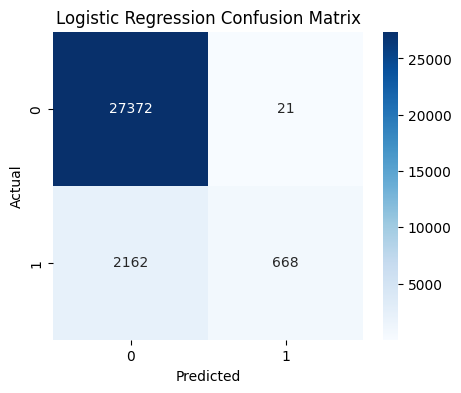

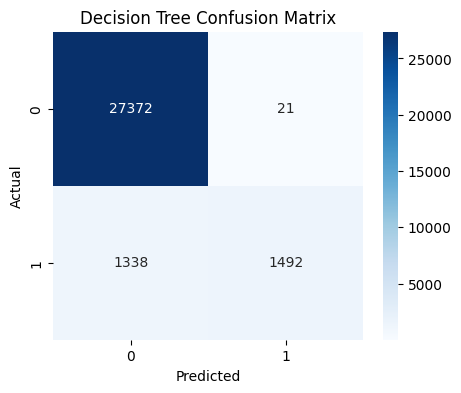

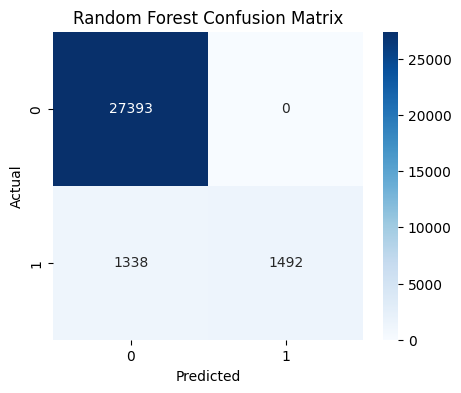

In [ ]:
# CONFUSION MATRICES
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf
}

for name, pred in models.items():

    cm = confusion_matrix(
        y_test,
        pred
    )

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{name} Confusion Matrix")

    plt.xlabel("Predicted")

    plt.ylabel("Actual")

    plt.show()

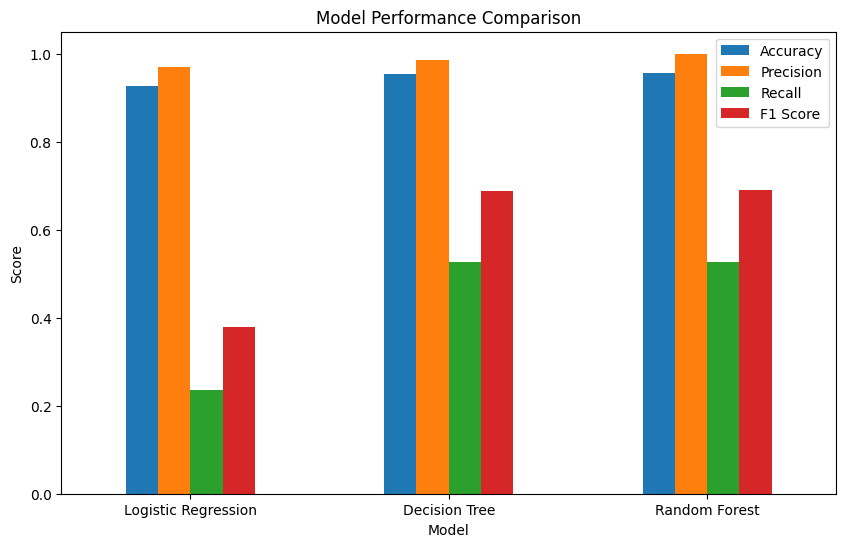

In [ ]:
# MODEL COMPARISON CHART
results_df.set_index("Model").plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

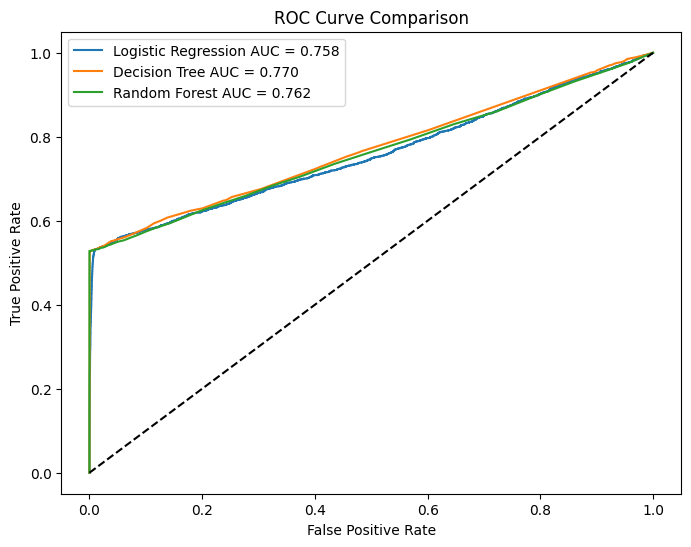

In [ ]:
# ROC CURVE
plt.figure(figsize=(8,6))

# Logistic Regression

lr_prob = lr.predict_proba(
    X_test_scaled
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    lr_prob
)

plt.plot(
    fpr,
    tpr,
    label=f'Logistic Regression AUC = {roc_auc_score(y_test, lr_prob):.3f}'
)

# Decision Tree

dt_prob = dt.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    dt_prob
)

plt.plot(
    fpr,
    tpr,
    label=f'Decision Tree AUC = {roc_auc_score(y_test, dt_prob):.3f}'
)

# Random Forest

rf_prob = rf.predict_proba(
    X_test
)[:,1]

fpr, tpr, _ = roc_curve(
    y_test,
    rf_prob
)

plt.plot(
    fpr,
    tpr,
    label=f'Random Forest AUC = {roc_auc_score(y_test, rf_prob):.3f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

                 Feature  Importance
5  time_difference_hours    0.424811
8         purchase_month    0.234772
7           purchase_day    0.085369
0         purchase_value    0.082017
4                    age    0.069374
6          purchase_hour    0.058872
2                browser    0.024133
3                    sex    0.013504
1                 source    0.007146


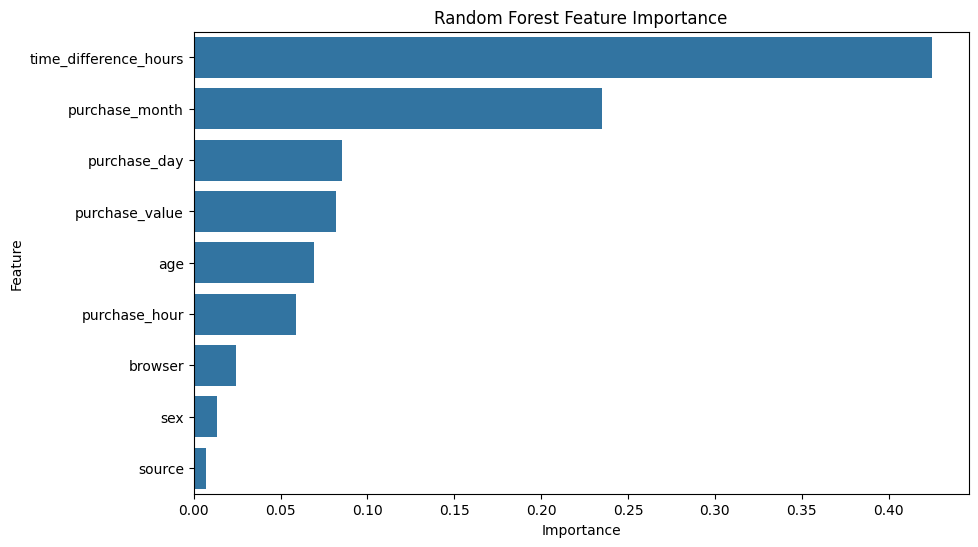

In [ ]:
# RANDOM FOREST FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Random Forest Feature Importance"
)

plt.show()